# Hafta 4: Yeni Nesil Dizileme Verisi: FASTQ Formatı ve Kalite Kontrol

**Biyoenformatiğe Giriş (Python & Biopython)**

**Bu haftanın hedefleri**
1. Yeni nesil dizileme (NGS) iş akışını ve FASTQ formatını tanımak.
2. Phred kalite skoru ile hata olasılığı arasındaki ilişkiyi hesaplamak.
3. Konum bazlı kalite, okuma başına ortalama kalite, GC dağılımı gibi QC grafiklerini üretmek.
4. Kalite filtresi, kayan pencere ile kırpma (trimming) ve adaptör kırpma algoritmalarını yazmak.

**Veri:** `okumalar.fastq` — 2000 adet 100 bazlık sentetik okuma (bir kısmı düşük kaliteli, bir kısmında adaptör var).

> **Kullanım:** Colab'da *Çalışma zamanı → Tümünü çalıştır* ile tüm hücreleri sırayla çalıştırabilirsiniz. Alıştırmaların çözümleri notebook'un sonundadır; önce kendiniz deneyin.

In [1]:
# Colab'da gerekli kütüphaneleri kur (yalnızca ilk çalıştırmada birkaç saniye sürer)
!pip -q install biopython 
import Bio
print('Biopython sürümü:', Bio.__version__)

Biopython sürümü: 1.88


In [2]:
# ---------------- VERİ SETİNİ HAZIRLA ----------------
# Veri dosyaları ders paketindeki 'veri' klasöründe de mevcuttur.
# İsterseniz Colab'ın sol panelinden 'veri' klasörü oluşturup dosyaları yükleyebilirsiniz;
# dosya bulunamazsa aşağıdaki fonksiyon(lar) AYNI veriyi (sabit tohum) yeniden üretir.
import os

def veri_uret_fastq(klasor="veri"):
    """okumalar.fastq: 2000 adet 100 bazlık sentetik Illumina benzeri okuma."""
    import os, random, math
    os.makedirs(klasor, exist_ok=True)
    rng = random.Random(7)
    genom = "".join(rng.choice("ACGT") for _ in range(5000))
    adaptor = "AGATCGGAAGAGCACACGTCTGAACTCCAGTCAC"
    L = 100
    satirlar = []
    for i in range(2000):
        kotu = rng.random() < 0.10
        adaptorlu = rng.random() < 0.08
        if adaptorlu:
            ins = rng.randint(55, 90)
            bas = rng.randint(0, len(genom) - ins)
            gercek = genom[bas:bas + ins] + adaptor
            gercek = (gercek + "".join(rng.choice("ACGT") for _ in range(L)))[:L]
        else:
            bas = rng.randint(0, len(genom) - L)
            gercek = genom[bas:bas + L]
        dizi, kal = [], []
        for j, b in enumerate(gercek):
            ort = (38 - 13 * (j / L) ** 2) if not kotu else (22 - 12 * j / L)
            q = int(round(rng.gauss(ort, 3)))
            q = max(2, min(41, q))
            if rng.random() < 0.002 or (kotu and rng.random() < 0.01):
                b, q = "N", 2
            elif rng.random() < 10 ** (-q / 10):
                b = rng.choice([x for x in "ACGT" if x != b])
            dizi.append(b)
            kal.append(chr(q + 33))
        satirlar += [f"@okuma_{i+1:04d} ornek=S1", "".join(dizi), "+", "".join(kal)]
    with open(os.path.join(klasor, "okumalar.fastq"), "w") as f:
        f.write("\n".join(satirlar) + "\n")


if not os.path.exists('veri/okumalar.fastq'):
    veri_uret_fastq()
print('veri klasörü:', sorted(os.listdir('veri')))


veri klasörü: ['1A8O.pdb', 'okumalar.fastq']


## 1. FASTQ formatı
Her okuma **4 satırdan** oluşur:
```
@okuma_0001 ornek=S1          <- 1. '@' + kimlik
GATTTGGGGTTCAAAGCAGTATCG...   <- 2. dizi
+                             <- 3. ayırıcı (isteğe bağlı olarak kimlik tekrarı)
IIIIHHHGGGFFF@@@???;;;99...   <- 4. her baz için bir kalite karakteri
```
**Phred skoru:** $Q = -10\log_{10} P_{hata}$ &nbsp;&nbsp; ⇔ &nbsp;&nbsp; $P_{hata} = 10^{-Q/10}$

Kalite karakteri: `chr(Q + 33)` (Sanger / Illumina 1.8+ kodlaması, "Phred+33").

| Q | Hata olasılığı | Doğruluk | ASCII karakteri |
|---|---|---|---|
| 10 | 1/10 | %90 | `+` |
| 20 | 1/100 | %99 | `5` |
| 30 | 1/1000 | %99.9 | `?` |
| 40 | 1/10000 | %99.99 | `I` |

In [3]:
for q in [10, 20, 30, 40]:
    print(f"Q={q}: P(hata)={10**(-q/10):.4f}, karakter='{chr(q+33)}'")

# Tersine: karakterden skora
kalite_satiri = "II?5+#"
print([ord(c) - 33 for c in kalite_satiri])

Q=10: P(hata)=0.1000, karakter='+'
Q=20: P(hata)=0.0100, karakter='5'
Q=30: P(hata)=0.0010, karakter='?'
Q=40: P(hata)=0.0001, karakter='I'
[40, 40, 30, 20, 10, 2]


### Sayısal örnek — Bir okumadaki beklenen hata sayısı
Beklenen hata sayısı, her bazın hata olasılıklarının toplamıdır: $E[\text{hata}] = \sum_i 10^{-Q_i/10}$

Kalite dizisi `II??55++` (Q = 40, 40, 30, 30, 20, 20, 10, 10) için:

$E = 2(10^{-4}) + 2(10^{-3}) + 2(10^{-2}) + 2(10^{-1}) = 0.0002+0.002+0.02+0.2 = 0.2222$

Yani bu 8 bazlık okumada ortalama 0.22 hata beklenir; hatanın büyük kısmı son iki bazdan gelir.

In [4]:
Q = [ord(c) - 33 for c in "II??55++"]
print("Q:", Q, "| beklenen hata:", round(sum(10**(-q/10) for q in Q), 4))

Q: [40, 40, 30, 30, 20, 20, 10, 10] | beklenen hata: 0.2222


## 2. FASTQ dosyasını okumak

In [5]:
print(open("veri/okumalar.fastq").read()[:440])

@okuma_0001 ornek=S1
CGATGCTAATATTCTGATTTGGGGTTGATTTGCGCTTCAGGCGCTAAAGTGGTTTTGAGTAACATGTCCTTTTGACGGGAGCAGGTCGCCTCAAGATAAG
+
IFDDICJEHHBEJEDFDDDDDJDFC@IG@IHJCEJ>BIDDEFGHFDEBDBGBGFCEADEFB=AABC@?DB?AE>>;@><C>?BC?>B:A;:?9<<78;6;
@okuma_0002 ornek=S1
GACGTCTTTCTGAGGGTCAGCCGTGATTCCGATTCGATTAGACTGGTCCCCACGGGTCCATGAGTACGAGGAAACTCGGTATCGAGCCTAAAAGTTATAA
+
J?JGJCFBHGHHFEJJJFFEHJHECE=JBHBEJF>GE>JHGCGFABFBEEFDCBEABBA>A=GAACHD?AEA@B;D>=9:<E;A>@?>9=>


In [6]:
from Bio import SeqIO

okumalar = list(SeqIO.parse("veri/okumalar.fastq", "fastq"))
print("Okuma sayısı:", len(okumalar))
r = okumalar[0]
print(r.id, len(r))
print("Dizi   :", r.seq[:40], "...")
print("Kalite :", r.letter_annotations["phred_quality"][:40], "...")

Okuma sayısı: 2000
okuma_0001 100
Dizi   : CGATGCTAATATTCTGATTTGGGGTTGATTTGCGCTTCAG ...
Kalite : [40, 37, 35, 35, 40, 34, 41, 36, 39, 39, 33, 36, 41, 36, 35, 37, 35, 35, 35, 35, 35, 41, 35, 37, 34, 31, 40, 38, 31, 40, 39, 41, 34, 36, 41, 29, 33, 40, 35, 35] ...


> **Performans ipucu:** Milyonlarca okuma için `SeqRecord` oluşturmak yavaştır.
`FastqGeneralIterator` sadece (başlık, dizi, kalite_dizgisi) üçlüsü döndürür ve çok daha hızlıdır.

In [7]:
import time
from Bio.SeqIO.QualityIO import FastqGeneralIterator

t = time.time(); n1 = sum(1 for _ in SeqIO.parse("veri/okumalar.fastq", "fastq")); t1 = time.time() - t
t = time.time()
with open("veri/okumalar.fastq") as h:
    n2 = sum(1 for _ in FastqGeneralIterator(h))
t2 = time.time() - t
print(f"SeqIO.parse: {t1*1000:.0f} ms | FastqGeneralIterator: {t2*1000:.0f} ms | hızlanma ≈ {t1/max(t2,1e-9):.0f}x")

SeqIO.parse: 9 ms | FastqGeneralIterator: 2 ms | hızlanma ≈ 4x


## 3. Kalite kontrol (QC) grafikleri
FastQC gibi araçların ürettiği temel grafikleri kendimiz çizelim.

Kalite matrisi boyutu: (2000, 100)


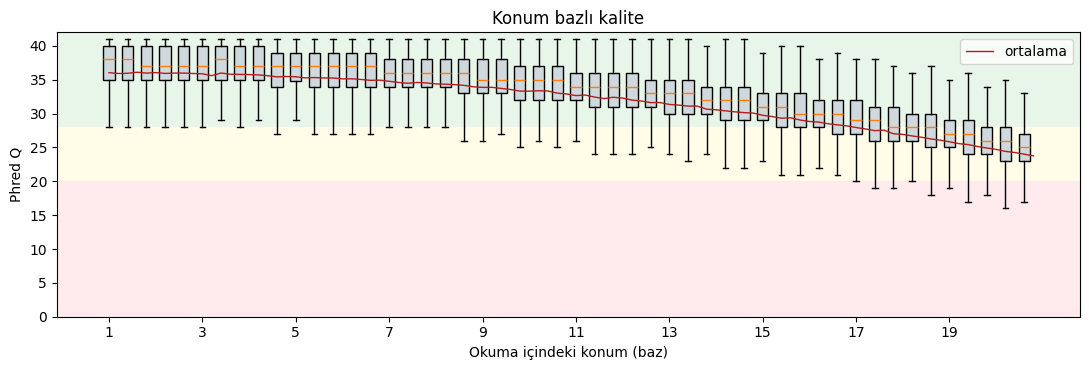

In [8]:
import numpy as np
import matplotlib.pyplot as plt

Qmat = np.array([r.letter_annotations["phred_quality"] for r in okumalar])   # (okuma, konum)
print("Kalite matrisi boyutu:", Qmat.shape)

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.axhspan(28, 42, color="#e8f5e9"); ax.axhspan(20, 28, color="#fffde7"); ax.axhspan(0, 20, color="#ffebee")
ax.boxplot([Qmat[:, i] for i in range(0, 100, 2)], positions=range(1, 101, 2), widths=1.2,
           showfliers=False, patch_artist=True, boxprops=dict(facecolor="#cfd8dc"))
ax.plot(range(1, 101), Qmat.mean(axis=0), color="#b71c1c", lw=1, label="ortalama")
ax.set_xticks(range(1, 101, 10)); ax.set_xlabel("Okuma içindeki konum (baz)"); ax.set_ylabel("Phred Q")
ax.set_title("Konum bazlı kalite"); ax.set_ylim(0, 42); ax.legend(); plt.tight_layout(); plt.show()

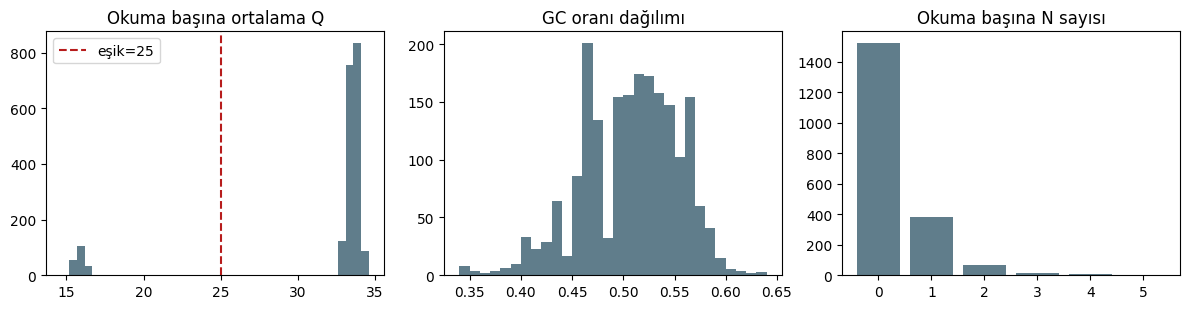

Ortalama Q < 25 olan okuma oranı: 10.0%


In [9]:
from Bio.SeqUtils import gc_fraction

ort_kalite = Qmat.mean(axis=1)
gc = np.array([gc_fraction(r.seq) for r in okumalar])
n_sayisi = np.array([r.seq.count("N") for r in okumalar])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
axes[0].hist(ort_kalite, bins=40, color="#607d8b"); axes[0].set_title("Okuma başına ortalama Q")
axes[0].axvline(25, color="#b71c1c", ls="--", label="eşik=25"); axes[0].legend()
axes[1].hist(gc, bins=30, color="#607d8b"); axes[1].set_title("GC oranı dağılımı")
axes[2].bar(*np.unique(n_sayisi, return_counts=True), color="#607d8b"); axes[2].set_title("Okuma başına N sayısı")
plt.tight_layout(); plt.show()
print(f"Ortalama Q < 25 olan okuma oranı: {(ort_kalite < 25).mean():.1%}")

## 4. Kalite filtreleme ve kırpma algoritmaları

**Akış:** ham okumalar → (1) adaptör kırpma → (2) kayan pencere kalite kırpma → (3) uzunluk filtresi → (4) ortalama kalite filtresi → temiz okumalar

### 4.1 Kayan pencere kırpma (Trimmomatic SLIDINGWINDOW benzeri)
Okuma 5'→3' taranır; `w` bazlık pencerenin ortalama kalitesi eşik değerinin altına ilk düştüğü yerden itibaren okuma kesilir.

**Elle örnek:** Q = [38, 37, 36, 30, 22, 18, 15, 12], w = 3, eşik = 25

| Pencere başı | Pencere | Ortalama | Eşik altı? |
|---|---|---|---|
| 0 | 38, 37, 36 | 37.0 | hayır |
| 1 | 37, 36, 30 | 34.3 | hayır |
| 2 | 36, 30, 22 | 29.3 | hayır |
| 3 | 30, 22, 18 | 23.3 | **evet** → konum 3'ten kes |

Sonuç: ilk 3 baz tutulur.

In [10]:
def kayan_pencere_kirp(kalite, w=4, esik=25):
    '''Tutulacak uzunluğu döndürür.'''
    for i in range(len(kalite) - w + 1):
        if sum(kalite[i:i + w]) / w < esik:
            return i
    return len(kalite)

print("Elle örnek:", kayan_pencere_kirp([38, 37, 36, 30, 22, 18, 15, 12], w=3, esik=25))   # 3

Elle örnek: 3


### 4.2 Adaptör kırpma
Kısa DNA parçalarında okuma, parçanın sonunu geçip adaptöre girer. Okumanın sonundaki adaptör başlangıcını arayalım
(en az `min_ortusme` baz, `max_hata` uyumsuzluğa izin vererek).

In [11]:
ADAPTOR = "AGATCGGAAGAGC"   # Illumina TruSeq adaptörünün başlangıcı

def adaptor_konumu(dizi, adaptor=ADAPTOR, min_ortusme=5, max_hata=1):
    dizi = str(dizi)
    for i in range(len(dizi) - min_ortusme + 1):
        parca = dizi[i:i + len(adaptor)]
        karsilastir = adaptor[:len(parca)]
        hata = sum(a != b for a, b in zip(parca, karsilastir))
        if hata <= (max_hata if len(parca) >= 8 else 0):
            return i
    return len(dizi)

ornek = "ACGTACGTTTGACAGATCGGAAGAGCACAC"
print("Adaptör başlangıcı:", adaptor_konumu(ornek), "->", ornek[:adaptor_konumu(ornek)])

Adaptör başlangıcı: 13 -> ACGTACGTTTGAC


In [12]:
def temizle(okuma, min_uzunluk=50, min_ort_q=25):
    a = adaptor_konumu(okuma.seq)
    okuma = okuma[:a]                                    # SeqRecord dilimleme kaliteyi de keser
    k = kayan_pencere_kirp(okuma.letter_annotations["phred_quality"])
    okuma = okuma[:k]
    if len(okuma) < min_uzunluk:
        return None, "kısa"
    q = okuma.letter_annotations["phred_quality"]
    if sum(q) / len(q) < min_ort_q:
        return None, "düşük kalite"
    if okuma.seq.count("N") > 2:
        return None, "N fazla"
    return okuma, "geçti"

from collections import Counter
sonuc, neden = [], Counter()
adaptor_bulunan = 0
for r in okumalar:
    if adaptor_konumu(r.seq) < len(r):
        adaptor_bulunan += 1
    t, d = temizle(r)
    neden[d] += 1
    if t is not None:
        sonuc.append(t)
SeqIO.write(sonuc, "temiz_okumalar.fastq", "fastq")
print("Adaptör içeren okuma:", adaptor_bulunan)
print("Filtre sonuçları:", dict(neden))

Adaptör içeren okuma: 150
Filtre sonuçları: {'geçti': 1793, 'kısa': 207}


In [13]:
import pandas as pd

def ozet(liste):
    uz = np.array([len(r) for r in liste])
    q = np.concatenate([r.letter_annotations["phred_quality"] for r in liste])
    return {"okuma sayısı": len(liste), "toplam baz": int(uz.sum()), "ortalama uzunluk": round(float(uz.mean()), 1),
            "ortalama Q": round(float(q.mean()), 2), "Q≥30 baz oranı": f"{(q >= 30).mean():.1%}"}

pd.DataFrame({"Ham": ozet(okumalar), "Temiz": ozet(sonuc)})

,Ham,Temiz
okuma sayısı,2000,1793
toplam baz,200000,165543
ortalama uzunluk,100.0,92.3
ortalama Q,31.84,34.17
Q≥30 baz oranı,71.6%,84.0%


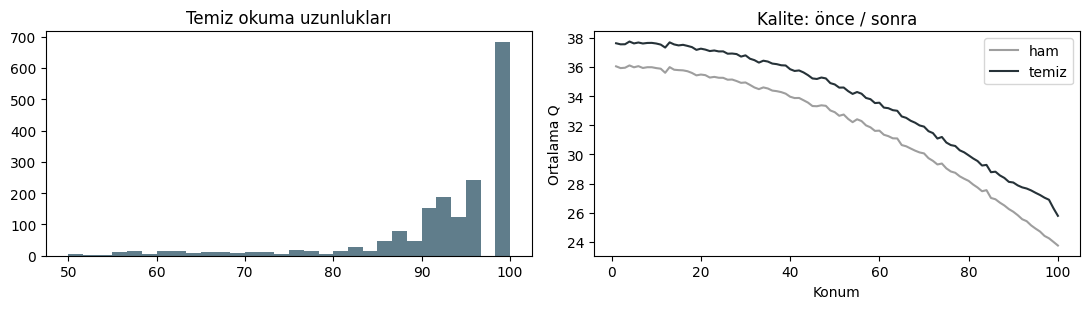

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist([len(r) for r in sonuc], bins=30, color="#607d8b"); ax[0].set_title("Temiz okuma uzunlukları")
Qt = np.full((len(sonuc), 100), np.nan)
for i, r in enumerate(sonuc):
    q = r.letter_annotations["phred_quality"]; Qt[i, :len(q)] = q
ax[1].plot(range(1, 101), np.nanmean(Qmat, axis=0), label="ham", color="#9e9e9e")
ax[1].plot(range(1, 101), np.nanmean(Qt, axis=0), label="temiz", color="#263238")
ax[1].set_xlabel("Konum"); ax[1].set_ylabel("Ortalama Q"); ax[1].legend(); ax[1].set_title("Kalite: önce / sonra")
plt.tight_layout(); plt.show()

## 5. Kapsama (coverage) hesabı — Lander–Waterman
Ortalama kapsama: $C = \dfrac{N \cdot L}{G}$ (N: okuma sayısı, L: okuma uzunluğu, G: genom boyu).
Poisson varsayımıyla bir bazın **hiç okunmama** olasılığı: $P(0) = e^{-C}$.

**Örnek:** 5 Mbp'lik bakteri genomu, 2×150 bp, 1 000 000 okuma çifti → $C = 2\,000\,000 \times 150 / 5\,000\,000 = 60\times$,
$P(0) = e^{-60} \approx 8.8\times10^{-27}$. Bizim veri: 2000 okuma × 100 bp / 5000 bp = 40×.

In [15]:
import math
for (N, L, G) in [(2_000_000, 150, 5_000_000), (2000, 100, 5000), (10_000, 100, 5_000_000)]:
    Cv = N * L / G
    print(f"N={N:>9,} L={L} G={G:>9,} -> C={Cv:6.2f}x, okunmamış baz oranı={math.exp(-Cv):.2e}, "
          f"beklenen okunmamış baz≈{G*math.exp(-Cv):,.0f}")

N=2,000,000 L=150 G=5,000,000 -> C= 60.00x, okunmamış baz oranı=8.76e-27, beklenen okunmamış baz≈0
N=    2,000 L=100 G=    5,000 -> C= 40.00x, okunmamış baz oranı=4.25e-18, beklenen okunmamış baz≈0
N=   10,000 L=100 G=5,000,000 -> C=  0.20x, okunmamış baz oranı=8.19e-01, beklenen okunmamış baz≈4,093,654


## 6. Alıştırmalar
1. Q=25 olan bir bazın hata olasılığı nedir? Kalite karakteri hangisidir?
2. 150 bazlık bir okumanın tüm bazları Q=30 ise beklenen hata sayısı kaçtır? En az bir hata olma olasılığı nedir?
3. `temizle` fonksiyonuna, okumanın **başındaki** (5') Q<20 bazları kesen bir adım ekleyin ve özet tabloyu yeniden üretin.
4. Temiz okumalarda konum bazlı **baz kompozisyonu** (A, C, G, T oranları) grafiğini çizin. Rastgele genom için ne beklersiniz?
5. 3 Gbp'lik bir genomun %99.9'undan fazlasının en az bir kez okunması için gereken minimum ortalama kapsama nedir?

---
## Çözümler

1) P=0.0032, karakter=':'
2) E=0.150, P(en az bir hata)=1-(1-p)^150=0.1394


3) {'okuma sayısı': 1793, 'toplam baz': 165539, 'ortalama uzunluk': 92.3, 'ortalama Q': 34.17, 'Q≥30 baz oranı': '84.0%'}


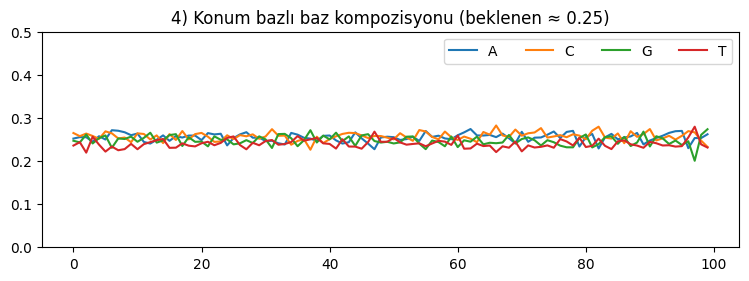

5) e^-C < 0.001 -> C > ln(1000) = 6.91x


In [16]:
# 1
print(f"1) P={10**-2.5:.4f}, karakter='{chr(25+33)}'")
# 2
p = 1e-3
print(f"2) E={150*p:.3f}, P(en az bir hata)=1-(1-p)^150={1-(1-p)**150:.4f}")
# 3
def bas_kirp(okuma, esik=20):
    q = okuma.letter_annotations["phred_quality"]
    i = 0
    while i < len(q) and q[i] < esik:
        i += 1
    return okuma[i:]
def temizle2(okuma, **kw):
    return temizle(bas_kirp(okuma), **kw)
sonuc2 = [t for t, d in (temizle2(r) for r in okumalar) if t is not None]
print("3)", ozet(sonuc2))
# 4
komp = np.zeros((4, 100)); say = np.zeros(100)
for r in sonuc:
    for i, b in enumerate(str(r.seq)):
        if b in "ACGT":
            komp["ACGT".index(b), i] += 1; say[i] += 1
plt.figure(figsize=(9, 2.8))
for j, b in enumerate("ACGT"):
    plt.plot(komp[j] / np.maximum(say, 1), label=b)
plt.ylim(0, 0.5); plt.legend(ncol=4); plt.title("4) Konum bazlı baz kompozisyonu (beklenen ≈ 0.25)"); plt.show()
# 5
print(f"5) e^-C < 0.001 -> C > ln(1000) = {math.log(1000):.2f}x")